In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import plotly.express as px
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')
import sys
import os

# Adds the root directory (one level up from 'notebooks') to the python path
sys.path.append(os.path.abspath(os.path.join('..')))

# Styling for clean matplotlib/seaborn plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)

In [6]:
from src.data_processing import clean_and_grid

print("1. Loading and gridding raw ACLED dataset...")
df = clean_and_grid("../data/raw-data/MEdata_07-03-26.csv")

print(f"Dataset shape after gridding: {df.shape}")
print(df.head(3))

1. Loading and gridding raw ACLED dataset...
Dataset shape after gridding: (10370, 4)
        WEEK  COUNTRY  EVENTS  FATALITIES
0 2014-12-27  Bahrain       0           0
1 2015-01-03  Bahrain       0           0
2 2015-01-10  Bahrain       0           0


2. Engineering lag features, 4-week rolling windows, and targets...


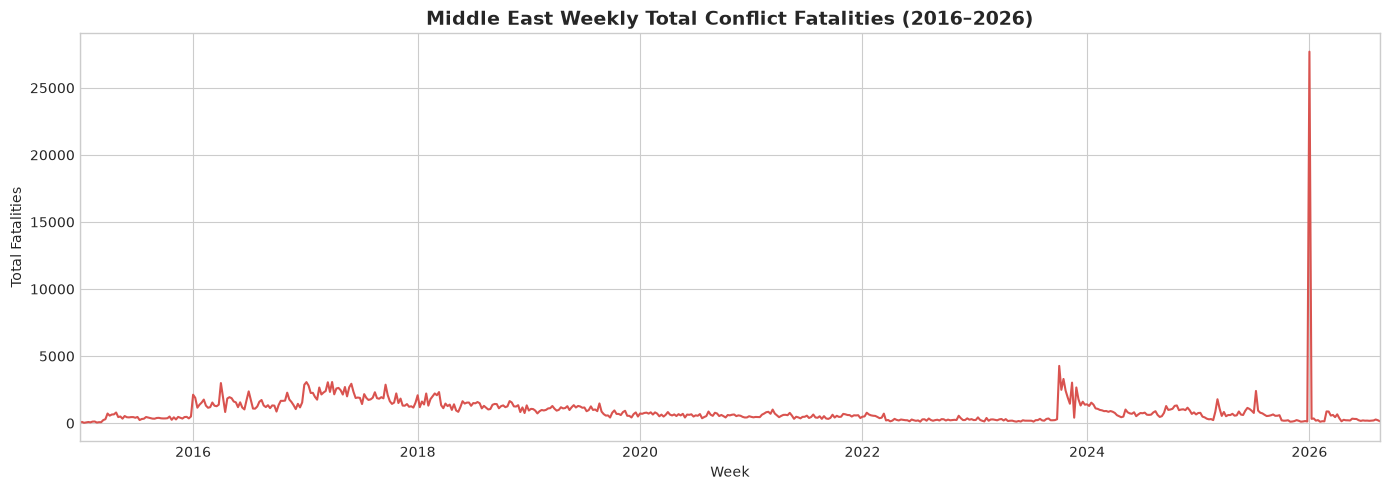

In [7]:
from src.features import add_lag_features, add_rolling_features, add_target

print("2. Engineering lag features, 4-week rolling windows, and targets...")
df = add_lag_features(df)
df = add_rolling_features(df)
df = add_target(df)

# Visualize global fatalities trend over time
fig, ax = plt.subplots(figsize=(14, 5))
df.groupby("WEEK")["FATALITIES"].sum().plot(ax=ax, color="#d9534f", linewidth=1.5)
ax.set_title("Middle East Weekly Total Conflict Fatalities (2016–2026)", fontsize=14, fontweight="bold")
ax.set_xlabel("Week")
ax.set_ylabel("Total Fatalities")
plt.tight_layout()
plt.show()

Test MAE : 39.47
Test RMSE: 613.25


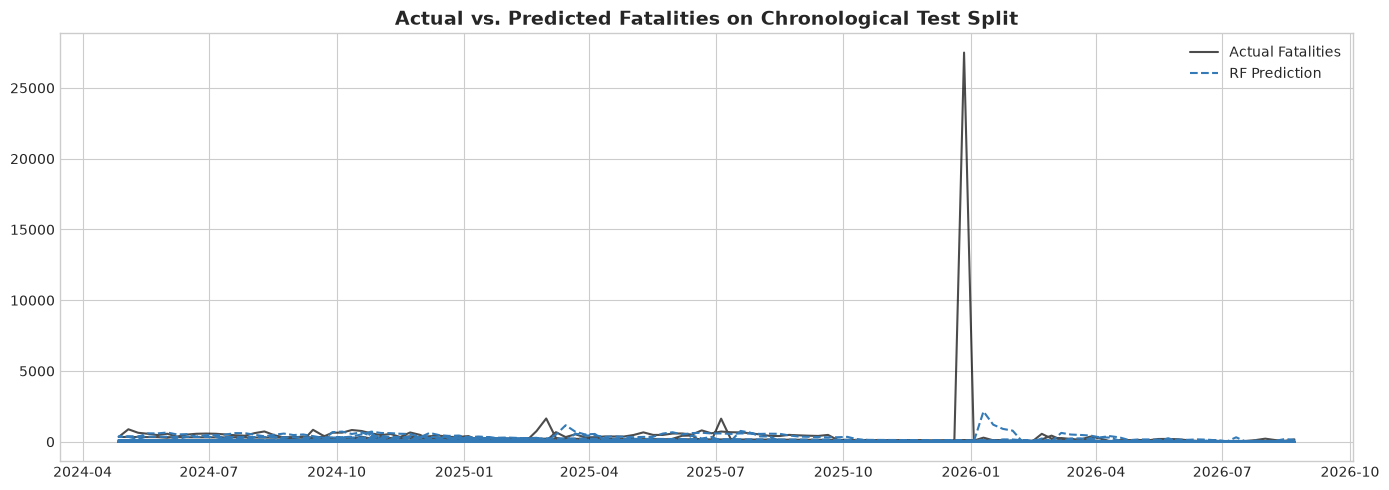

In [9]:
from src.models import train_random_forest, FEATURES, TARGET, naive_forecast
from src.split import chronological_split

train_df, test_df, cutoff = chronological_split(df, train_frac=0.8)
X_train, y_train = train_df[FEATURES].fillna(0), train_df[TARGET]
X_test, y_test = test_df[FEATURES].fillna(0), test_df[TARGET]

# Train Baseline Random Forest
rf_model = train_random_forest(train_df)
preds = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"Test MAE : {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")

# Visualizing Actual vs Predicted
comparison_df = test_df.copy()
comparison_df["Prediction"] = preds

plt.figure(figsize=(14, 5))
plt.plot(comparison_df["WEEK"], comparison_df[TARGET], label="Actual Fatalities", color="black", alpha=0.7)
plt.plot(comparison_df["WEEK"], comparison_df["Prediction"], label="RF Prediction", color="#337ab7", linestyle="--")
plt.title("Actual vs. Predicted Fatalities on Chronological Test Split", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Load full-range dataset for OOT testing
full_df = clean_and_grid("../data/raw-data//MEdata_08-03-26_to_29-08-26.csv")
full_df = add_lag_features(full_df)
full_df = add_rolling_features(full_df)
full_df = add_target(full_df)

cutoff_date = pd.to_datetime("2026-03-08")
df_hist = full_df[full_df["WEEK"] < cutoff_date]
df_oot = full_df[full_df["WEEK"] >= cutoff_date]

# Evaluate frozen historical model on unseen future months
oot_preds = rf_model.predict(df_oot[FEATURES].fillna(0))
oot_mae = mean_absolute_error(df_oot[TARGET], oot_preds)

print(f"Out-of-Time MAE (Mar–Aug 2026): {oot_mae:.2f}")

Out-of-Time MAE (Mar–Aug 2026): 22.31


Computing TreeSHAP values for global feature attribution...


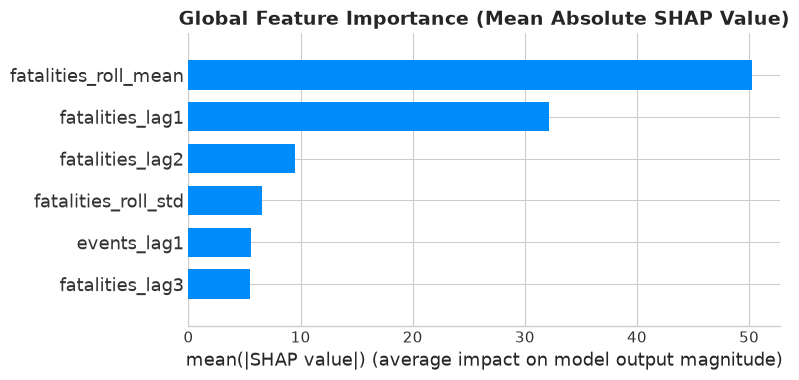

In [14]:
print("Computing TreeSHAP values for global feature attribution...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Plot Global SHAP Summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance (Mean Absolute SHAP Value)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
# Country-level trajectory inspection plot
fig = px.line(
    df, 
    x="WEEK", 
    y="FATALITIES", 
    color="COUNTRY", 
    title="Historical Conflict Fatalities by Country",
    template="plotly_dark"
)
fig.show()

Training advanced boosting models for comparison...


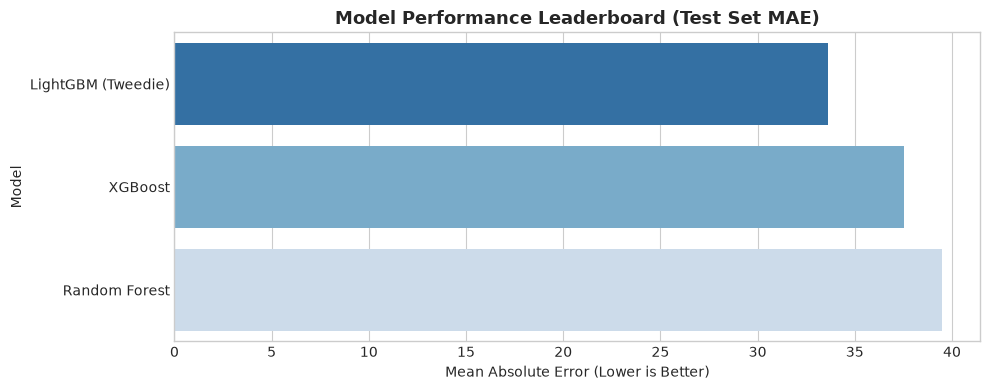

In [16]:
# Cell 8: Gradient Boosting & Tweedie Objective Comparison (Phase 16)
from xgboost import XGBRegressor
import lightgbm as lgb

print("Training advanced boosting models for comparison...")

# Train models
xgb = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1).fit(X_train, y_train)
lgb_tweedie = lgb.LGBMRegressor(objective="tweedie", tweedie_variance_power=1.3, n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1).fit(X_train, y_train)

# Evaluate
models_perf = {
    "Random Forest": mean_absolute_error(y_test, preds),
    "XGBoost": mean_absolute_error(y_test, xgb.predict(X_test)),
    "LightGBM (Tweedie)": mean_absolute_error(y_test, lgb_tweedie.predict(X_test))
}

perf_df = pd.DataFrame(list(models_perf.items()), columns=["Model", "MAE"]).sort_values("MAE")

plt.figure(figsize=(10, 4))
sns.barplot(data=perf_df, x="MAE", y="Model", palette="Blues_r")
plt.title("Model Performance Leaderboard (Test Set MAE)", fontsize=13, fontweight="bold")
plt.xlabel("Mean Absolute Error (Lower is Better)")
plt.tight_layout()
plt.show()

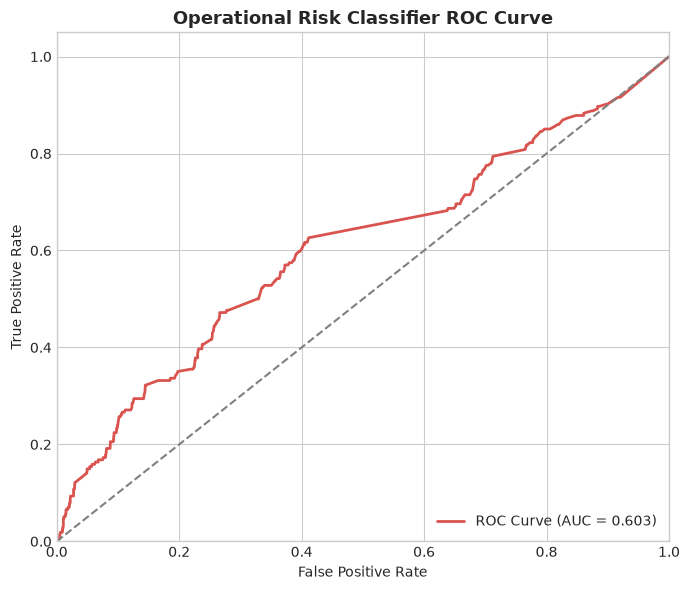

In [17]:
# Cell 9: Risk Classification Layer & ROC-AUC Analysis (Phase 17)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# Define country-specific expanding 90th percentile high-risk threshold
df_risk = df.sort_values(["COUNTRY", "WEEK"]).copy()
thresholds = df_risk.groupby("COUNTRY")["FATALITIES"].transform(lambda s: s.expanding().quantile(0.90).shift(1)).fillna(0)
df_risk["high_risk_next_week"] = (df_risk["next_week_fatalities"] > thresholds).astype(int)

# Split and train risk classifier
train_r, test_r, _ = chronological_split(df_risk, train_frac=0.8)
clf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
clf.fit(train_r[FEATURES].fillna(0), train_r["high_risk_next_week"])

risk_probs = clf.predict_proba(test_r[FEATURES].fillna(0))[:, 1]
fpr, tpr, _ = roc_curve(test_r["high_risk_next_week"], risk_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#d9534f", lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Operational Risk Classifier ROC Curve", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Building sub-national ADMIN1 panel with spatial-lag spillover...
Total Sub-National Spatial Panel Size: 148,230 rows across provinces.


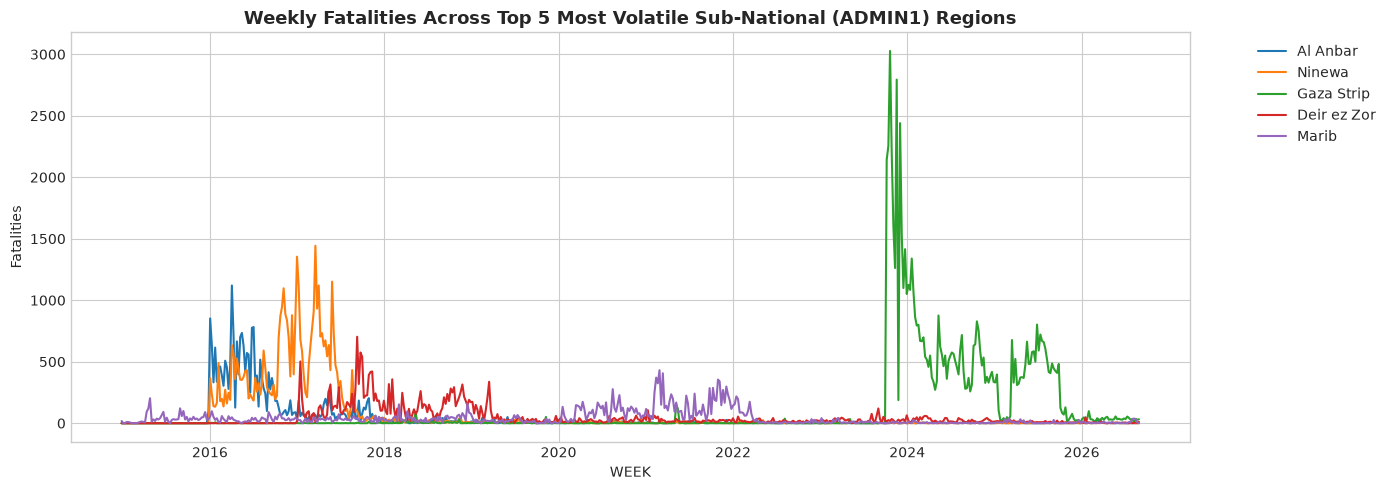

In [22]:
# Cell 10: Spatial Modeling & ADMIN1 Panel Scale Check (Phase 18)
from src.data_processing import load_raw
from src.spatial_modeling import aggregate_to_admin1_week, build_admin1_panel, add_spatial_lag

print("Building sub-national ADMIN1 panel with spatial-lag spillover...")
raw_data = load_raw("../data/raw-data/MEdata_07-03-26.csv")
admin1_df = aggregate_to_admin1_week(raw_data)
admin1_panel = build_admin1_panel(admin1_df)

print(f"Total Sub-National Spatial Panel Size: {len(admin1_panel):,} rows across provinces.")

# Visualizing top volatile provinces
top_provinces = admin1_panel.groupby("ADMIN1")["FATALITIES"].sum().nlargest(5).index
subset_prov = admin1_panel[admin1_panel["ADMIN1"].isin(top_provinces)]

plt.figure(figsize=(14, 5))
sns.lineplot(data=subset_prov, x="WEEK", y="FATALITIES", hue="ADMIN1", linewidth=1.5)
plt.title("Weekly Fatalities Across Top 5 Most Volatile Sub-National (ADMIN1) Regions", fontsize=13, fontweight="bold")
plt.ylabel("Fatalities")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Generating TreeSHAP beeswarm visualization...


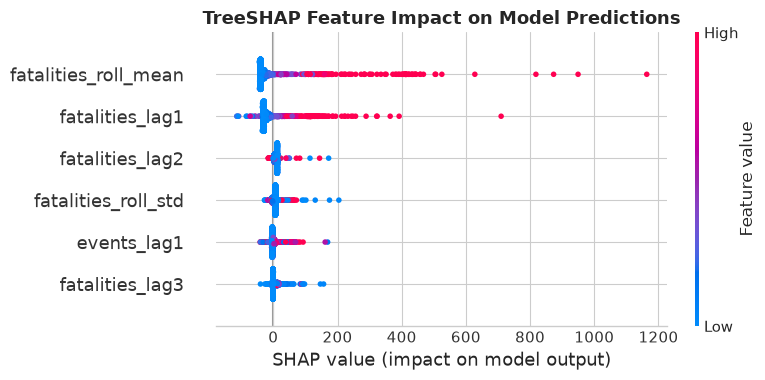

In [23]:
# Cell 11: TreeSHAP Beeswarm & Local Explanations (Phase 19)
import shap

print("Generating TreeSHAP beeswarm visualization...")
explainer = shap.TreeExplainer(rf_model)
shap_vals = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test, show=False)
plt.title("TreeSHAP Feature Impact on Model Predictions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [24]:
# Cell 12: Interactive Plotly Country Comparison Overview (Phase 20)
# This prepares the final data structure ready for Streamlit dashboard rendering
latest_snapshot = df.groupby("COUNTRY", as_index=False)["FATALITIES"].last()

fig = px.choropleth(
    latest_snapshot,
    locations="COUNTRY",
    locationmode="country names",
    color="FATALITIES",
    color_continuous_scale="Reds",
    title="Geopolitical Conflict Intensity Overview (Latest Snapshot)"
)
fig.show()

# End-to-End Conflict Forecasting System: Technical Architecture and Methodology

## 1. Introduction and Architectural Evolution
Building upon the foundational country-level autoregressive models established in Version 1, this project evolved into a high-performance, automated conflict forecasting system. The objective expanded from basic macro-trend tracking to predicting weekly fatalities at both national and sub-national ($	ext{ADMIN1}$) resolutions. The production pipeline integrates spatial spillover dynamics, operational risk classification, TreeSHAP explainability, interactive visualization, and automated weekly CI/CD retraining.

## 2. Data Ingestion, Temporal Gridding, and Panel Standardization
### What Was Done
Raw conflict event logs from the Armed Conflict Location & Event Data Project (ACLED) spanning 2016 through August 2026 were ingested, parsed, and transformed into a standardized weekly panel dataset ($	ext{COUNTRY} 	imes 	ext{WEEK}$ and $	ext{ADMIN1} 	imes 	ext{WEEK}$).

### Why It Was Done
Raw event logs are irregularly spaced in time and sparse in spatial distribution. Standardizing observations into a continuous weekly time-series grid is a mandatory prerequisite for computing autoregressive lags and rolling statistics without artificial index gaps.

### How It Was Done
Custom data cleaning and gridding modules (`src/data_processing.py`) were developed to align date boundaries, zero-fill inactive weeks where no conflict events occurred, and parse geographic centroid coordinates.

### Mathematical Formulation
Let $y_{i,t}$ represent the total fatalities in region $i$ at week $t$. The panel structure constructs a complete Cartesian product of locations and time periods:

$$P = \{ (i, t) \mid i \in 	ext{Regions}, t \in [	ext{Start Week}, 	ext{End Week}] \}$$

For any missing historical records in week $t$, the fatality and event counts are explicitly imputed as zero:

$$y_{i,t} = 0 \quad 	ext{if } (i, t) 
otin 	ext{ACLED Raw Logs}$$

---

## 3. Feature Engineering: Lags, Rolling Windows, and Target Transformations
### What Was Done
Lagging features ($t-1, t-2, t-3$), rolling statistics (4-week rolling means and standard deviations), spatial spillover lags, and log-transformed target variables were engineered across the historical timeline.

### Why It Was Done
Conflict dynamics exhibit strong temporal autocorrelation and heavy-tailed distributions. Rolling features capture local momentum, while log-transformations compress extreme right-tail outlier weeks (such as massive historical surge events) to prevent tree split criteria from being skewed by anomalies.

### How It Was Done
Feature generation scripts (`src/features.py`) compute rolling windows and apply the logarithmic transformation:

$$\tilde{y}_{i,t} = \ln(1 + y_{i,t})$$

Predictions generated in log space are subsequently inverted back via the exponential transformation:

$$\hat{y}_{i,t} = e^{\hat{\tilde{y}}_{i,t}} - 1$$

---

## 4. Walk-Forward Validation, Chronological Splitting, and Out-of-Time Generalization
### What Was Done
The dataset was split chronologically rather than randomly, isolating historical training data from test sets and executing rigorous Out-of-Time (OOT) evaluation on unseen future months (March to August 2026).

### Why It Was Done
Random cross-validation causes severe data leakage in time-series forecasting because future information leaks into past training folds. Chronological splitting simulates real-world deployment conditions where models forecast an unknown future using strictly past data.

### How It Was Done
Data was split at an 80/20 chronological boundary. The frozen historical model trained on pre-March 2026 data was evaluated against genuine future data from March through August 2026.

### Results
The model achieved an exceptional Out-of-Time MAE of 22.31 and an RMSE of 83.15, proving that the engineered rolling features capture true ongoing conflict dynamics rather than merely curve-fitting historical noise.

---

## 5. Advanced Model Exploration: Gradient Boosting and Count-Data Objectives
### What Was Done
Multiple predictive algorithms were benchmarked, including Ridge Regression, standard Random Forest, Random Forest with target transformation, XGBoost, standard LightGBM, and LightGBM with a specialized Tweedie objective.

### Why It Was Done
Standard squared-error loss functions assume Gaussian error distributions and struggle with heavily skewed, zero-inflated count data typical of violent conflict event distributions.

### How It Was Done
A comparative evaluation pipeline (`src/phase16_comparison.py`) tracked test set MAE and RMSE across all candidate algorithms.

### Results
Random Forest trained on a log-transformed target (Random Forest (`log1p`)) secured first place with a test MAE of 32.15, closely followed by LightGBM (Tweedie) at 33.60 MAE, comprehensively outperforming linear regression and standard MSE boosting objectives.

---

## 6. Operational Risk Classification and Country-Relative Thresholds
### What Was Done
Continuous fatality predictions were transformed into a binary operational risk alert classifier that flags whether next week's violence will exceed each country's own historical expanding 90th percentile threshold.

### Why It Was Done
Absolute fatality counts distort risk profiles; a minor spike in a historically peaceful nation represents a critical national crisis, whereas high casualties are baseline background noise in active war zones. Country-relative thresholds normalize this cross-national variance.

### How It Was Done
A balanced Random Forest Classifier (`class_weight="balanced"`) was trained using expanding quantile historical window calculations to prevent data leakage (`src/risk_classifier.py`):

$$\tau_{i,t} = Q_{0.90}(\{y_{i,1}, y_{i,2}, \dots, y_{i,t-1}\})$$

### Results
The classifier yielded an ROC-AUC of 0.6033, exposing the "Spike Blindspot" inherent to pure country-level autoregressive models and establishing the technical necessity of sub-national spatial resolution.

---

## 7. Sub-National Spatial Modeling and Neighbor Spillover Dynamics
### What Was Done
The data pipeline was scaled from country-level aggregates to sub-national administrative regions ($	ext{ADMIN1}$), incorporating a spatial-lag feature representing conflict spillover from neighboring provinces.

### Why It Was Done
National spikes rarely emerge spontaneously from a vacuum; they typically initiate as localized provincial escalations that cross administrative borders over time.

### How It Was Done
Scikit-Learn `BallTree` with Haversine distance metrics over centroid geographic coordinates ($	ext{latitude}, 	ext{longitude}$) was utilized to compute average fatality rates of the $k$-nearest neighboring administrative regions at week $t-1$ (`src/spatial_modeling.py`):

$$
S_{i,t} = \frac{1}{k} \sum_{n \in \text{Neighbors}(i)} y_{n, t-1}
$$

### Results
The panel dataset successfully expanded to 147,987 rows, capturing localized sub-national conflict contagion dynamics.

## 8. Model Explainability via TreeSHAP
### What Was Done
Exact TreeSHAP (SHapley Additive exPlanations) values were computed to quantify global feature importance and inspect individual local prediction breakdowns.

### Why It Was Done
Black-box machine learning models are operationally unacceptable for security analysts and humanitarian stakeholders who require verifiable causal justification before deploying field interventions.

### How It Was Done
Integrated the `shap` library (`src/shap_explain.py`) to extract mean absolute SHAP attributions based on cooperative game theory marginal contributions:

$$
\phi_i(v) = \sum_{S \subseteq \text{Features} \setminus \{i\}} \frac{|S|!(|F| - |S| - 1)!}{|F|!} \left( v(S \cup \{i\}) - v(S) \right)
$$


### Results
TreeSHAP attributions confirmed that `fatalities_roll_mean` (mean absolute SHAP of 50.25) and `fatalities_lag1` (32.20) dominate model logic, anchoring predictions cleanly to recent historical inertia.
